In [ ]:
import pandas as pd
import numpy as np

# This creates student_data.csv directly in Colab
data = {
    'Student_ID': range(1, 101),
    'Attendance': np.random.randint(60, 105, 100),
    'Study_Hours': np.random.randint(2, 20, 100),
    'Prev_CGPA': np.round(np.random.uniform(5.0, 9.5, 100), 2),
    'Assignments_Avg': np.random.randint(40, 100, 100),
    'Final_Marks': np.random.randint(50, 100, 100)
}

df = pd.DataFrame(data)
# Add some problems to practice cleaning
df.loc[5:10, 'Attendance'] = None
df.loc[15, 'Attendance'] = 120

df.to_csv('student_data.csv', index=False)
print("✅ student_data.csv created in Colab!")
print(df.head())

✅ student_data.csv created in Colab!
   Student_ID  Attendance  Study_Hours  Prev_CGPA  Assignments_Avg  \
0           1       101.0           11       8.15               45   
1           2        72.0            7       7.39               48   
2           3        76.0           14       8.89               87   
3           4        82.0            9       7.78               97   
4           5        99.0            4       8.31               96   

   Final_Marks  
0           75  
1           99  
2           60  
3           88  
4           80  


# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'IMG-20250328-WA0010.jpg',
 'Khushi aiml',
 'main-2.gdoc',
 'myself (1).gdoc',
 'Untitled form (1).gform',
 'Untitled presentation (9).gslides',
 'Untitled presentation (8).gslides',
 'Untitled presentation (7).gslides',
 'Untitled presentation (6).gslides',
 '2a682f8e-7315-44e6-ba01-b4f35a466f05.gdoc',
 'Untitled presentation (5).gslides',
 'Definition of a Palindrome.gdoc',
 'Project proposal.gdoc',
 'Untitled form.gform',
 'Case study.gslides',
 'Untitled presentation (4).gslides',
 'Travel planner.gsheet',
 'Untitled presentation (3).gslides',
 'Untitled presentation (2).gslides',
 'Untitled presentation (1).gslides',
 'Untitled presentation.gslides',
 'This is kchill .gform',
 '22_Series_Draft_TT_III_Sem_Jan_-Feb_2026_0001_copy.pdf',
 'StudentsPerformance.csv',
 'untitled']

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/StudentsPerformance.csv')

print("First 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                        

In [ ]:
print("Shape:", df.shape)  # rows, columns
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (1000, 8)

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0


In [ ]:
df.columns = ['gender', 'race_ethnicity', 'parental_education',
              'lunch', 'test_preparation_course', 'math_score',
              'reading_score', 'writing_score']
print(df.columns)

Index(['gender', 'race_ethnicity', 'parental_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [ ]:
print(df.dtypes)
print("\nUnique values in categorical columns:")
print(df['test_preparation_course'].value_counts())

gender                     object
race_ethnicity             object
parental_education         object
lunch                      object
test_preparation_course    object
math_score                  int64
reading_score               int64
writing_score               int64
dtype: object

Unique values in categorical columns:
test_preparation_course
none         642
completed    358
Name: count, dtype: int64


In [ ]:
print(df.describe())

       math_score  reading_score  writing_score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [ ]:
df.groupby('test_preparation_course')[['math_score', 'reading_score', 'writing_score']].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


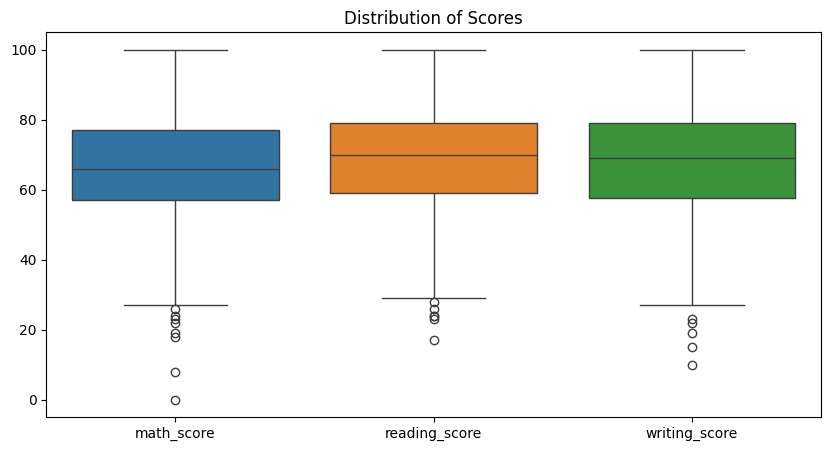

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['math_score', 'reading_score', 'writing_score']])
plt.title('Distribution of Scores')
plt.show()

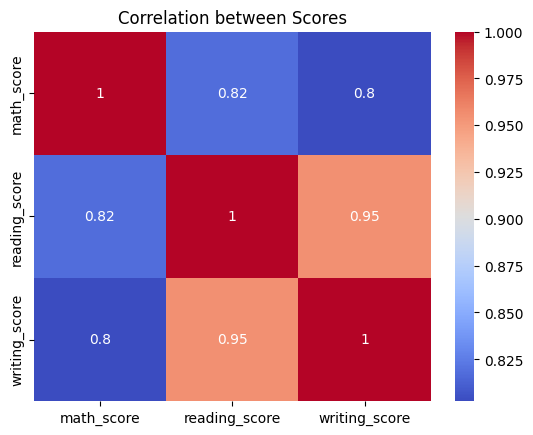

In [ ]:
import seaborn as sns
sns.heatmap(df[['math_score', 'reading_score', 'writing_score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Scores')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Convert text columns to numbers
df_ml = pd.get_dummies(df, columns=['gender', 'race_ethnicity', 'parental_education', 'lunch', 'test_preparation_course'])

X = df_ml.drop('math_score', axis=1)
y = df_ml['math_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8804332983749567
Mean Absolute Error: 4.214763142474848


In [ ]:
import pandas as pd
import numpy as np

# Feature importance
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeff_df['Abs_Coefficient'] = np.abs(coeff_df['Coefficient'])
coeff_df = coeff_df.sort_values('Abs_Coefficient', ascending=False)

print("Top 5 factors affecting Math Score:")
print(coeff_df.head())

Top 5 factors affecting Math Score:
                   Feature  Coefficient  Abs_Coefficient
2            gender_female    -6.532442         6.532442
3              gender_male     6.532442         6.532442
8   race_ethnicity_group E     4.090025         4.090025
15      lunch_free/reduced    -1.755037         1.755037
16          lunch_standard     1.755037         1.755037
